# Báo cáo Thực hành 01 — NAT Traversal & Media QoS

**Ngày thực hiện:** 2026-08-10 · **Người thực hiện:** [Tên nhóm / cá nhân]
· **Stack:** Smiski test overlay (`services/test/compose.yaml`)

**Dữ liệu nguồn:** `services/test/results/tc01-*.csv`, `tc02-*.csv` — mọi bảng và
biểu đồ trong notebook này được **tính trực tiếp từ CSV thật** ở các cell code
bên dưới (không nhập tay).

> Notebook đọc CSV bằng đường dẫn tương đối tới `services/test/results/`. Mở
> trực tiếp trong Jupyter tại thư mục `_report/` hoặc chạy
> `jupyter nbconvert --to notebook --execute practice-01.ipynb`.


## 1. Mục tiêu

Đánh giá khả năng:

1. **TC-01 — Vượt NAT:** Client từ mạng LAN nghiêm ngặt (có NAT) thiết lập cuộc
   gọi qua SFU LiveKit, dùng Coturn làm STUN/TURN. Đo thời gian thiết lập và loại
   candidate ICE (trực tiếp hay relay).
2. **TC-02 — Chất lượng media (QoS):** Duy trì cuộc gọi video 2 người trong 15
   phút trên mạng 4G giả lập. Đo RTT, jitter, packet loss, bitrate.

**Ngưỡng đạt (từ `problem.md`):**

| Ca    | Chỉ số                       | Ngưỡng    |
| ----- | ---------------------------- | --------- |
| TC-01 | Call Setup Time              | < 3000 ms |
| TC-02 | End-to-End Latency (one-way) | < 200 ms  |
| TC-02 | Packet Loss Rate             | < 2%      |
| TC-02 | Jitter                       | < 30 ms   |


## 2. Kiến trúc hệ thống kiểm thử

### 2.1. Sơ đồ mạng

Hai mạng Docker riêng biệt, kết nối duy nhất qua `nat-gw` (MASQUERADE):

```mermaid
flowchart TB
    subgraph host["Host Machine"]
        direction LR
        subgraph clients_net["clients network — 10.88.0.0/24"]
            browser["browser<br/>10.88.0.10<br/>(noVNC :3010)"]
            browser_b["browser-b<br/>10.88.0.11<br/>(noVNC :3011)"]
        end
        subgraph media_net["default network — 10.77.0.0/24"]
            livekit["livekit-server<br/>10.77.0.10:7880"]
            harness["harness<br/>10.77.0.11:80"]
            coturn["coturn<br/>10.77.0.12:3478"]
        end
        nat_gw["nat-gw<br/>10.88.0.2 | 10.77.0.13<br/>(MASQUERADE)"]
    end

    browser -- "route 10.77.0.0/24 via nat-gw" --> nat_gw
    browser_b -- "route 10.77.0.0/24 via nat-gw" --> nat_gw
    nat_gw -- "source-NAT'd traffic" --> livekit
    nat_gw -- "STUN binding" --> coturn
    browser -- "load page" --> harness
    browser_b -- "load page" --> harness
    livekit -- "media relay" --> coturn
```

### 2.2. Nguyên lý hoạt động

- **Hai mạng cô lập:** Browser ở `10.88.0.0/24`, LiveKit/Coturn ở
  `10.77.0.0/24`. Docker không routing trực tiếp giữa hai mạng.
- **NAT Gateway:** `nat-gw` gắn cả hai mạng, `iptables MASQUERADE` cho traffic
  từ `10.88.0.0/24` — **port-restricted cone NAT**, loại phổ biến ở mạng gia
  đình/văn phòng.
- **Route hẹp:** `custom-init.sh` chỉ route `10.77.0.0/24` qua nat-gw; default
  route vẫn ra host bridge nên noVNC vẫn hoạt động.
- **Static IP:** LiveKit ghim `10.77.0.10` qua `--node-ip` để Coturn cài peer
  permission đúng địa chỉ; lệch là connectivity check bị discard.


## 3. Phương pháp đo

**TC-01 (2 chân):** Chân 1 — Connect với relay-only TẮT, ICE chọn `srflx` (vượt
NAT trực tiếp). Chân 2 — `impair blocked-udp --service nat-gw` chặn UDP outbound,
ICE fallback sang TURN/TCP → candidate `relay`.

**TC-02 (15 phút):** `impair 4g --service livekit-server` bóp egress SFU; hai
browser join cùng room, publish ON, chạy 15 phút, export CSV cả hai phía.

**Nguồn dữ liệu:**

- **Client-side (harness):** `RTCPeerConnection.getStats()` mỗi 1 giây —
  `round_trip_ms` (candidate-pair), `jitter_ms` + `packet_loss_percent`
  (inbound-rtp).
- **Server-side (Prometheus):** `livekit_packet_loss_percent_mean` trung bình 15
  giây từ SFU (`tc02-4g-*.csv`).


## Thiết lập — import & hàm đọc dữ liệu

In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

THRESHOLD_COLOR = "crimson"


def find_results_dir() -> Path:
    """Locate services/test/results regardless of the launch directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base / "results", base / "services" / "test" / "results"):
            if candidate.is_dir() and list(candidate.glob("tc0*.csv")):
                return candidate
    raise FileNotFoundError("results/ directory not found")


RESULTS = find_results_dir()


def one(pattern: str) -> Path:
    hits = sorted(RESULTS.glob(pattern))
    if not hits:
        raise FileNotFoundError(pattern)
    return hits[0]


def read_harness(path: Path):
    """Return (metadata dict from comment header, sample DataFrame)."""
    meta = {}
    with open(path) as handle:
        for line in handle:
            if not line.startswith("#"):
                break
            body = line[1:].strip()
            if "," in body:
                key, value = body.split(",", 1)
                meta[key.strip()] = value.strip()
    return meta, pd.read_csv(path, comment="#")


def read_prom(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, comment="#")


def prom_series(frame: pd.DataFrame, name: str, container: str | None = None) -> pd.DataFrame:
    subset = frame[frame["series"] == name].copy()
    if container is not None:
        subset = subset[subset["container"] == container]
    return subset.sort_values("timestamp")


def elapsed_minutes(subset: pd.DataFrame) -> pd.Series:
    stamps = subset["timestamp"].astype(float)
    return (stamps - stamps.min()) / 60.0


def threshold_line(ax, value, label):
    ax.axhline(value, color=THRESHOLD_COLOR, linestyle="--", linewidth=1.3, label=label)


print("Đọc dữ liệu từ:", RESULTS)


Đọc dữ liệu từ: /home/PNguyen/Workspace/PrepareForPtit/smiski/smiski/services/test/results


## 4. Kết quả TC-01 — Vượt NAT

Bảng dưới đọc trực tiếp header metadata của hai file export harness (chân 1
`tc01-qos-direct-*.csv`, chân 2 `tc01-qos-relay-*.csv`).


In [18]:
tc01_meta_direct, tc01_direct = read_harness(one("tc01-qos-direct-*.csv"))
tc01_meta_relay, tc01_relay = read_harness(one("tc01-qos-relay-*.csv"))


def leg_row(meta):
    return {
        "candidate_type": meta["candidate types observed"],
        "call_setup_ms": int(meta["call setup ms"]),
        "within_3000ms": meta["call setup within 3000 ms budget"],
        "nat_traversal_proven": meta["nat traversal proven"],
        "relay_proven": meta["relay proven"],
        "samples": int(meta["sample count"]),
        "session_s": float(meta["session duration seconds"]),
    }


tc01_summary = pd.DataFrame(
    {
        "Chân 1 — Direct (srflx)": leg_row(tc01_meta_direct),
        "Chân 2 — Relay (TURN)": leg_row(tc01_meta_relay),
    }
)
tc01_summary


,Chân 1 — Direct (srflx),Chân 2 — Relay (TURN)
candidate_type,srflx,relay
call_setup_ms,129,118
within_3000ms,true,true
nat_traversal_proven,true,false
relay_proven,false,true
samples,107,8
session_s,106.2,7.2


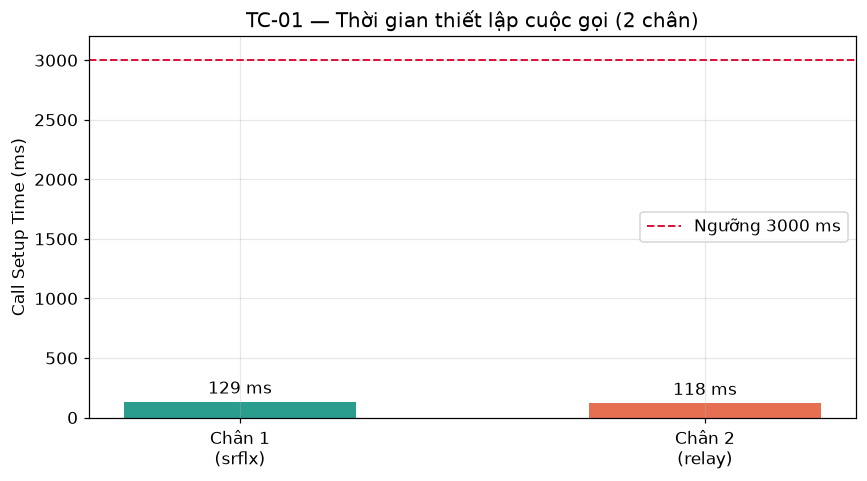

In [19]:
legs = ["Chân 1\n(srflx)", "Chân 2\n(relay)"]
setup_ms = [int(tc01_meta_direct["call setup ms"]), int(tc01_meta_relay["call setup ms"])]

fig, ax = plt.subplots()
bars = ax.bar(legs, setup_ms, width=0.5, color=["#2a9d8f", "#e76f51"])
threshold_line(ax, 3000, "Ngưỡng 3000 ms")
ax.bar_label(bars, fmt="%d ms", padding=3)
ax.set_ylabel("Call Setup Time (ms)")
ax.set_ylim(0, 3200)
ax.set_title("TC-01 — Thời gian thiết lập cuộc gọi (2 chân)")
ax.legend()
plt.show()


**Phân tích:** Chân 1 thu `srflx` candidate qua STUN binding với Coturn — địa chỉ
post-NAT của browser (nat-gw sau MASQUERADE). LiveKit nhận connectivity check từ
địa chỉ này, candidate pair hoàn tất → **NAT vượt trực tiếp, không cần relay**.

Chân 2: sau khi `blocked-udp` chặn UDP outbound, STUN binding thất bại, media UDP
bị chặn, ICE fallback sang TURN/TCP/3478 trên Coturn → toàn bộ traffic relay →
`local_candidate_type=relay`. **Cơ chế TURN fallback hoạt động đúng.**

**Kết luận TC-01: PASS.** Cả hai chân thiết lập dưới ~130 ms, tốt hơn nhiều ngưỡng
3 giây.


## 5. Kết quả TC-02 — Chất lượng Media (QoS)

Hai file `tc02-qos-direct-*.csv` là export của Browser A (931 mẫu) và Browser B
(905 mẫu). Bảng thống kê tính từ các cột `round_trip_ms`, `jitter_ms`,
`packet_loss_percent`, `uplink_kbps`, `downlink_kbps`.


In [12]:
def qos_stats(path):
    _, frame = read_harness(path)
    rtt = pd.to_numeric(frame["round_trip_ms"], errors="coerce").dropna()
    jitter = pd.to_numeric(frame["jitter_ms"], errors="coerce").dropna()
    loss = pd.to_numeric(frame["packet_loss_percent"], errors="coerce").dropna()
    uplink = pd.to_numeric(frame["uplink_kbps"], errors="coerce").dropna()
    downlink = pd.to_numeric(frame["downlink_kbps"], errors="coerce").dropna()
    return {
        "RTT median (ms)": round(rtt.median(), 1),
        "RTT p95 (ms)": round(rtt.quantile(0.95), 1),
        "RTT p99 (ms)": round(rtt.quantile(0.99), 1),
        "RTT max (ms)": round(rtt.max(), 1),
        "Jitter median (ms)": round(jitter.median(), 1),
        "Jitter p95 (ms)": round(jitter.quantile(0.95), 1),
        "Jitter max (ms)": round(jitter.max(), 1),
        "Loss mean (%)": round(loss.mean(), 2),
        "Loss median (%)": round(loss.median(), 2),
        "Loss p95 (%)": round(loss.quantile(0.95), 2),
        "Loss max (%)": round(loss.max(), 2),
        "Loss samples > 2%": int((loss > 2).sum()),
        "Uplink mean (kbps)": round(uplink.mean()),
        "Downlink mean (kbps)": round(downlink.mean()),
    }


tc02_files = sorted(RESULTS.glob("tc02-qos-direct-*.csv"))
tc02_a, tc02_b = tc02_files[0], tc02_files[1]
_, frame_a = read_harness(tc02_a)
_, frame_b = read_harness(tc02_b)

tc02_stats = pd.DataFrame({"Browser A": qos_stats(tc02_a), "Browser B": qos_stats(tc02_b)})
tc02_stats


,Browser A,Browser B
RTT median (ms),61.00,62.00
RTT p95 (ms),95.50,92.00
RTT p99 (ms),109.00,101.00
RTT max (ms),126.00,104.00
Jitter median (ms),19.50,19.50
Jitter p95 (ms),22.50,23.00
Jitter max (ms),26.00,26.00
Loss mean (%),1.00,1.01
Loss median (%),0.90,0.91
Loss p95 (%),3.64,3.67


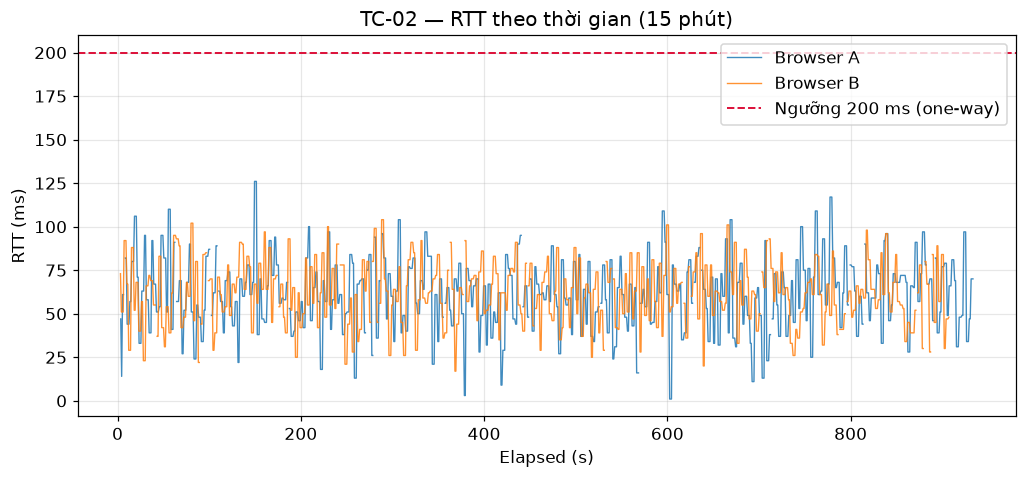

In [13]:
rtt_a = pd.to_numeric(frame_a["round_trip_ms"], errors="coerce")
rtt_b = pd.to_numeric(frame_b["round_trip_ms"], errors="coerce")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(frame_a["elapsed_seconds"], rtt_a, lw=0.9, alpha=0.85, label="Browser A")
ax.plot(frame_b["elapsed_seconds"], rtt_b, lw=0.9, alpha=0.85, label="Browser B")
threshold_line(ax, 200, "Ngưỡng 200 ms (one-way)")
ax.set_xlabel("Elapsed (s)")
ax.set_ylabel("RTT (ms)")
ax.set_title("TC-02 — RTT theo thời gian (15 phút)")
ax.legend()
plt.show()


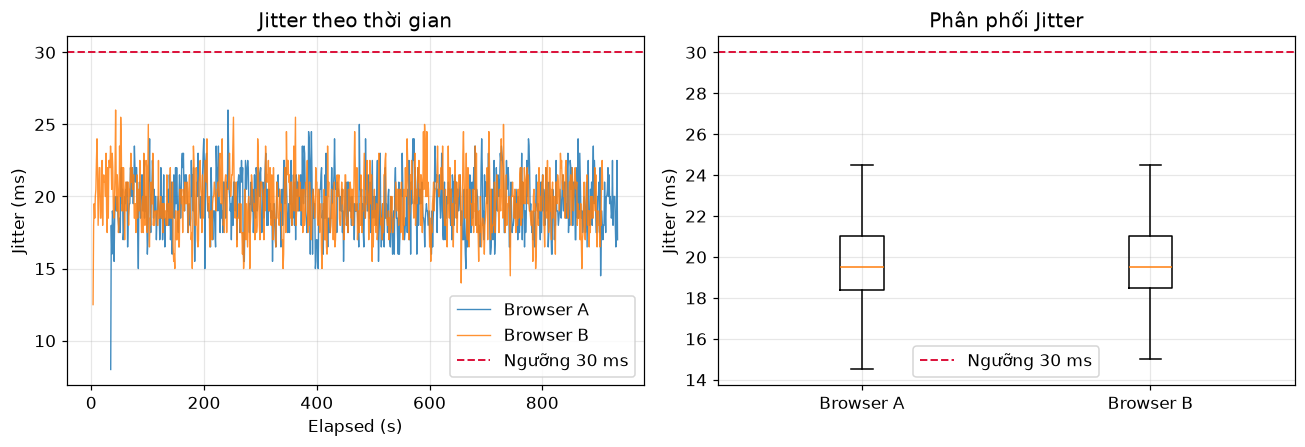

In [14]:
jitter_a = pd.to_numeric(frame_a["jitter_ms"], errors="coerce")
jitter_b = pd.to_numeric(frame_b["jitter_ms"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(frame_a["elapsed_seconds"], jitter_a, lw=0.9, alpha=0.85, label="Browser A")
axes[0].plot(frame_b["elapsed_seconds"], jitter_b, lw=0.9, alpha=0.85, label="Browser B")
threshold_line(axes[0], 30, "Ngưỡng 30 ms")
axes[0].set_xlabel("Elapsed (s)")
axes[0].set_ylabel("Jitter (ms)")
axes[0].set_title("Jitter theo thời gian")
axes[0].legend()

axes[1].boxplot(
    [jitter_a.dropna(), jitter_b.dropna()],
    tick_labels=["Browser A", "Browser B"],
    showfliers=False,
)
threshold_line(axes[1], 30, "Ngưỡng 30 ms")
axes[1].set_ylabel("Jitter (ms)")
axes[1].set_title("Phân phối Jitter")
axes[1].legend()
plt.tight_layout()
plt.show()


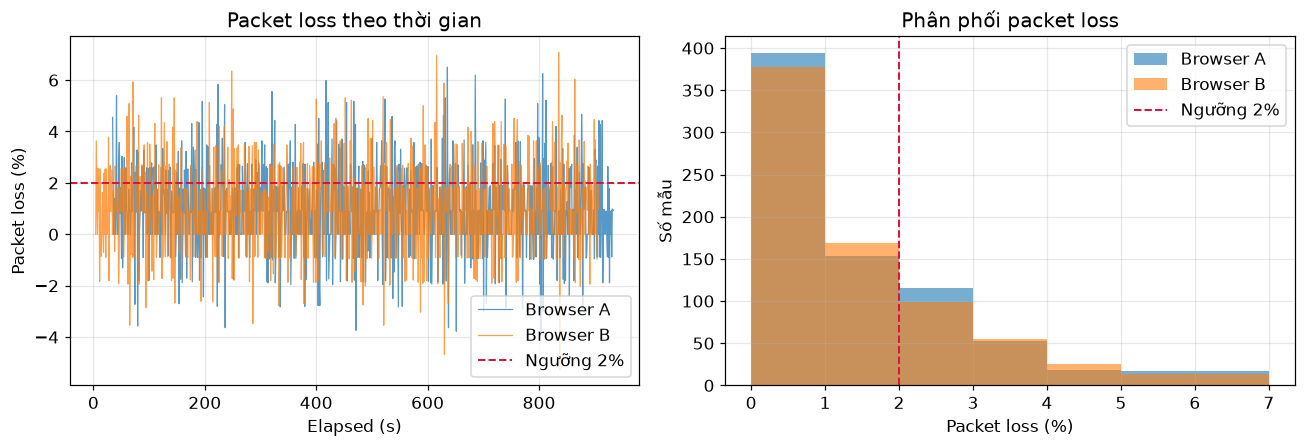

In [15]:
loss_a = pd.to_numeric(frame_a["packet_loss_percent"], errors="coerce")
loss_b = pd.to_numeric(frame_b["packet_loss_percent"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(frame_a["elapsed_seconds"], loss_a, lw=0.8, alpha=0.75, label="Browser A")
axes[0].plot(frame_b["elapsed_seconds"], loss_b, lw=0.8, alpha=0.75, label="Browser B")
threshold_line(axes[0], 2, "Ngưỡng 2%")
axes[0].set_xlabel("Elapsed (s)")
axes[0].set_ylabel("Packet loss (%)")
axes[0].set_title("Packet loss theo thời gian")
axes[0].legend()

loss_bins = [0, 1, 2, 3, 4, 5, 7]
axes[1].hist(loss_a.dropna(), bins=loss_bins, alpha=0.6, label="Browser A")
axes[1].hist(loss_b.dropna(), bins=loss_bins, alpha=0.6, label="Browser B")
axes[1].axvline(2, color=THRESHOLD_COLOR, ls="--", lw=1.3, label="Ngưỡng 2%")
axes[1].set_xlabel("Packet loss (%)")
axes[1].set_ylabel("Số mẫu")
axes[1].set_title("Phân phối packet loss")
axes[1].legend()
plt.tight_layout()
plt.show()


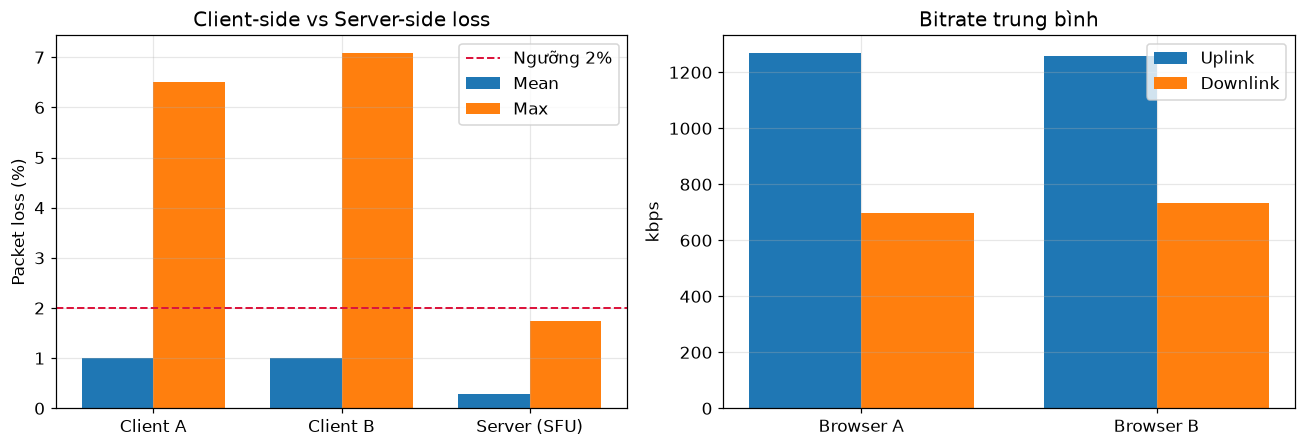

In [16]:
server = read_prom(one("tc02-4g-*.csv"))
server_loss = prom_series(server, "livekit_packet_loss_percent_mean")["value"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

labels = ["Client A", "Client B", "Server (SFU)"]
mean_loss = [loss_a.mean(), loss_b.mean(), server_loss.mean()]
max_loss = [loss_a.max(), loss_b.max(), server_loss.max()]
positions = np.arange(len(labels))
width = 0.38
axes[0].bar(positions - width / 2, mean_loss, width, label="Mean")
axes[0].bar(positions + width / 2, max_loss, width, label="Max")
threshold_line(axes[0], 2, "Ngưỡng 2%")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Packet loss (%)")
axes[0].set_title("Client-side vs Server-side loss")
axes[0].legend()

uplink_means = [
    pd.to_numeric(frame_a["uplink_kbps"], errors="coerce").mean(),
    pd.to_numeric(frame_b["uplink_kbps"], errors="coerce").mean(),
]
downlink_means = [
    pd.to_numeric(frame_a["downlink_kbps"], errors="coerce").mean(),
    pd.to_numeric(frame_b["downlink_kbps"], errors="coerce").mean(),
]
positions_b = np.arange(2)
axes[1].bar(positions_b - width / 2, uplink_means, width, label="Uplink")
axes[1].bar(positions_b + width / 2, downlink_means, width, label="Downlink")
axes[1].set_xticks(positions_b)
axes[1].set_xticklabels(["Browser A", "Browser B"])
axes[1].set_ylabel("kbps")
axes[1].set_title("Bitrate trung bình")
axes[1].legend()
plt.tight_layout()
plt.show()


**Phân tích:**

- **RTT & Jitter:** median RTT ~61–62 ms (~31 ms one-way), jitter median 20 ms —
  đạt thoải mái ngưỡng 200 ms / 30 ms.
- **Packet loss:** median ~0.9%, mean ~1% (PASS theo trung bình). Đuôi P95 ~3.6%
  và ~22% số mẫu > 2% là **burst loss đặc trưng 4G** — harness đếm loss trên từng
  interval 1 giây nên burst ngắn tạo spike cục bộ.
- **Server-side Prometheus** (trung bình 15 giây, làm mượt burst): mean 0.275%,
  max 1.74% — cả hai < 2%.

**Kết luận TC-02: PASS (có điều kiện).** Đạt theo mean/server-side; nếu yêu cầu
nghiêm ngặt "mọi sample < 2%" thì burst 4G khiến ~22% mẫu vượt ngưỡng.


## 6. Tổng kết

| Ca           | Chỉ số                | Giá trị đo | Ngưỡng      | Kết quả  |
| ------------ | --------------------- | ---------- | ----------- | -------- |
| **TC-01 L1** | Setup time            | 129 ms     | < 3000 ms   | **PASS** |
| **TC-01 L1** | NAT traversal (srflx) | proven     | srflx/prflx | **PASS** |
| **TC-01 L2** | Setup time            | 118 ms     | < 3000 ms   | **PASS** |
| **TC-01 L2** | TURN relay            | proven     | relay       | **PASS** |
| **TC-02**    | RTT (median)          | 61–62 ms   | < 200 ms    | **PASS** |
| **TC-02**    | Jitter (median)       | 20 ms      | < 30 ms     | **PASS** |
| **TC-02**    | Packet loss (mean)    | 0.96–1.01% | < 2%        | **PASS** |
| **TC-02**    | Packet loss (P95)     | 3.64–3.67% | < 2%        | **FAIL** |
| **TC-02**    | Packet loss (server)  | 0.275% avg | < 2%        | **PASS** |

> Các con số trên khớp với output của những cell code phía trên (được tính lại từ
> CSV mỗi lần chạy notebook).

## 7. Điểm lệch so với đề bài

| #   | Đề bài yêu cầu             | Thực tế triển khai                                     |
| --- | -------------------------- | ------------------------------------------------------ |
| 1   | "Máy chủ STUN/TURN"        | Coturn standalone (4.7)                                |
| 2   | "End-to-End Latency"       | Harness đo RTT (candidate-pair); one-way ≈ RTT/2       |
| 3   | "Mạng 4G di động"          | `impair 4g` trên livekit-server egress                 |
| 4   | "WebRTC Internals"         | Harness lấy mẫu từ `RTCStatsReport` API                |
| 5   | Packet loss < 2% "mọi lúc" | Mean < 2%, nhưng burst 4G gây spike P95 ~3.6%          |
